<!-- Import the necessary libraries -->

<!-- Creating a mapping of ID and code  -->

<!-- Creating a CodeBERT model -->

<!-- DATA TRANSFORMATION -->

<!-- Predicting values -->

  0%|          | 0/6422 [00:00<?, ?it/s]

/tmp/ipykernel_106/2982784710.py:31: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  prob=F.softmax(logits)


Accuracy: 0.9506384303955154
F1 Score: 0.9487800937146551
Precision: 0.9858965748824715
Recall: 0.9143568981625662


<Axes: >

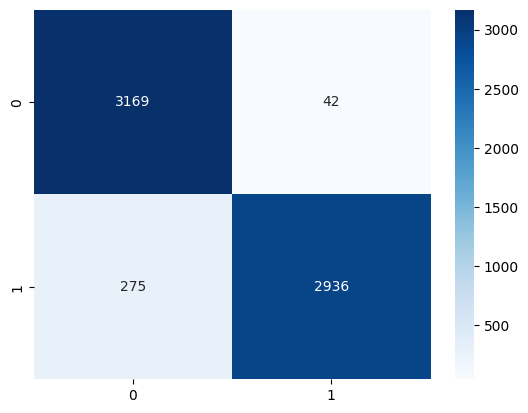

In [18]:
import tensorflow_datasets as tfds
import tensorflow as tf
from transformers import (RobertaConfig, RobertaModel, RobertaTokenizer)
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import json
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
import re
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import CrossEntropyLoss

# Load Data
url_to_code = {}
with open('/kaggle/input/bigclonebench-128/data.jsonl') as f:
    for line in f:
        js = json.loads(line.strip())
        url_to_code[js['idx']] = js['func']

# Load Model & Tokenizer
config = RobertaConfig.from_pretrained('microsoft/codebert-base')
model = RobertaModel.from_pretrained('microsoft/codebert-base')
tokenizer = RobertaTokenizer.from_pretrained('microsoft/codebert-base')

# Load trained model
model = Model(model, config, tokenizer)
model_path = '/kaggle/input/best-model/model.bin'
model.load_state_dict(torch.load(model_path, map_location=torch.device("cpu")), strict=False)
model.to(torch.device("cpu"))

# Load Test Data
data = pd.read_csv('/kaggle/input/subset-types/big_clone_test_subset_types.csv')
datalabels = data['labels'].to_list()
syntactic_types = data['syntactic_types'].to_list()
code_ids = data['code_ids'].apply(lambda x: eval(x)).to_list()

# Remove Comments
def replacer(match):
    s = match.group(0)
    return " " if s.startswith('/') else s

def remove_comments_and_docstrings(code):
    pattern = re.compile(r'//.*?$|/\*.*?\*/|\'(?:\\.|[^\\\'])*\'|"(?:\\.|[^\\"])*"', re.DOTALL | re.MULTILINE)
    return '\n'.join([x for x in re.sub(pattern, replacer, code).split('\n') if x.strip() != ""])

# Convert Code to Model Input
def convert_examples_to_features(code_1, code_2, remove_comments):
    if remove_comments:
        code_1 = remove_comments_and_docstrings(code_1)
        code_2 = remove_comments_and_docstrings(code_2)

    code1_tokens = tokenizer.tokenize(code_1)[:400 - 2]
    code1_ids = tokenizer.convert_tokens_to_ids([tokenizer.cls_token] + code1_tokens + [tokenizer.sep_token])
    code1_ids += [tokenizer.pad_token_id] * (400 - len(code1_ids))

    code2_tokens = tokenizer.tokenize(code_2)[:400 - 2]
    code2_ids = tokenizer.convert_tokens_to_ids([tokenizer.cls_token] + code2_tokens + [tokenizer.sep_token])
    code2_ids += [tokenizer.pad_token_id] * (400 - len(code2_ids))

    return torch.tensor(code1_ids + code2_ids).to(torch.device("cpu"))

# Predict
remove_comments = True
predictions = []

for ids, label in tqdm(zip(code_ids, datalabels), total=len(datalabels)): 
    code_1 = url_to_code[ids[0]]
    code_2 = url_to_code[ids[1]]

    input_ids = convert_examples_to_features(code_1, code_2, remove_comments)
    prediction = model(input_ids)
    predictions.append(int(torch.argmax(prediction)))

# Metrics
print('Accuracy:', accuracy_score(datalabels, predictions))
print('F1 Score:', f1_score(datalabels, predictions))
print('Precision:', precision_score(datalabels, predictions))
print('Recall:', recall_score(datalabels, predictions))

# Confusion Matrix
cf = confusion_matrix(datalabels, predictions, labels=[0, 1])
sns.heatmap(cf, annot=True, cmap='Blues', fmt="d")


In [22]:
from sklearn.metrics import classification_report

report = classification_report(datalabels, predictions, output_dict=True)

# Print accuracy separately
accuracy = report["accuracy"]
print(f"Accuracy: {accuracy:.4f}")

# Convert the report to a DataFrame (excluding 'accuracy' since it's not a class-wise metric)
df_report = pd.DataFrame(report).T

# Print the full classification report
print(df_report)


Accuracy: 0.9506
              precision    recall  f1-score      support
0              0.920151  0.986920  0.952367  3211.000000
1              0.985897  0.914357  0.948780  3211.000000
accuracy       0.950638  0.950638  0.950638     0.950638
macro avg      0.953024  0.950638  0.950573  6422.000000
weighted avg   0.953024  0.950638  0.950573  6422.000000


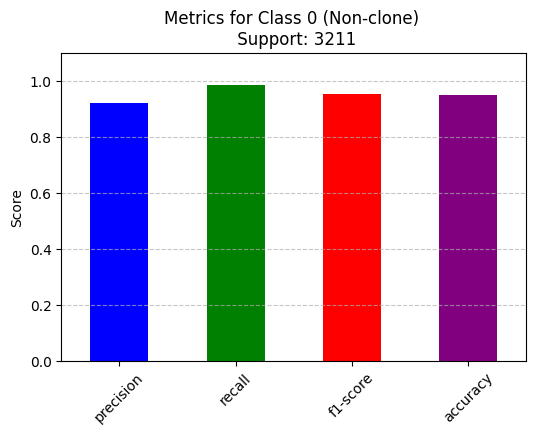

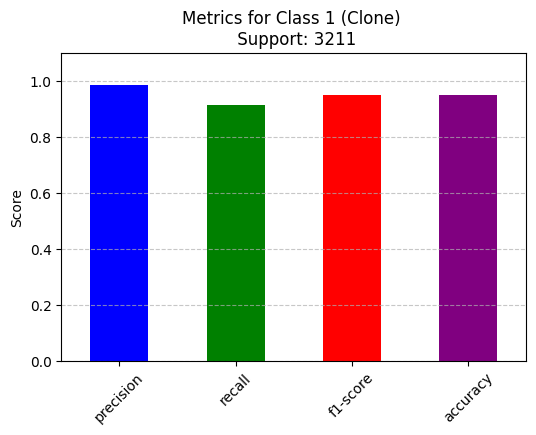

In [30]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report

# Generate classification report
report = classification_report(datalabels, predictions, output_dict=True)

# Convert to DataFrame
df_report = pd.DataFrame(report).T.iloc[:-1, :]  # Remove 'accuracy' row

# Extract data for Class 0 and Class 1
df_class_0 = df_report.loc['0', ['precision', 'recall', 'f1-score']].copy()
df_class_1 = df_report.loc['1', ['precision', 'recall', 'f1-score']].copy()

# Extract accuracy and add it to both classes
accuracy = report["accuracy"]
df_class_0["accuracy"] = accuracy
df_class_1["accuracy"] = accuracy

# Plot Class 0
plt.figure(figsize=(6, 4))
df_class_0.plot(kind='bar', color=['blue', 'green', 'red', 'purple'])
plt.title(f"Metrics for Class 0 (Non-clone) \n Support: {int(df_report.loc['0', 'support'])}")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Plot Class 1
plt.figure(figsize=(6, 4))
df_class_1.plot(kind='bar', color=['blue', 'green', 'red', 'purple'])
plt.title(f"Metrics for Class 1 (Clone) \n Support: {int(df_report.loc['1', 'support'])}")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


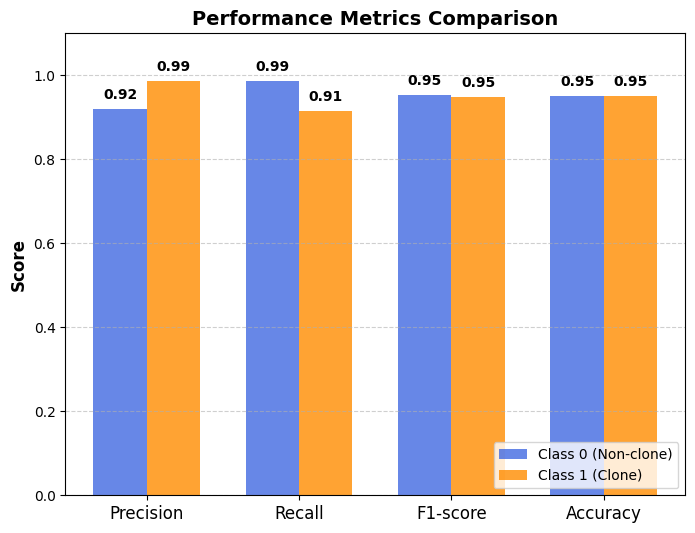

In [31]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report

# Generate classification report
report = classification_report(datalabels, predictions, output_dict=True)

# Convert to DataFrame
df_report = pd.DataFrame(report).T.iloc[:-1, :]  # Remove 'accuracy' row

# Extract Class 0 and Class 1 metrics
metrics = ['precision', 'recall', 'f1-score']
df_class_0 = df_report.loc['0', metrics].copy()
df_class_1 = df_report.loc['1', metrics].copy()

# Extract accuracy and add it to both classes
accuracy = report["accuracy"]
df_class_0["accuracy"] = accuracy
df_class_1["accuracy"] = accuracy

# Prepare labels and values
labels = ['Precision', 'Recall', 'F1-score', 'Accuracy']
values_class_0 = df_class_0.values
values_class_1 = df_class_1.values

# Define positions for grouped bars
x = np.arange(len(labels))
width = 0.35  

# Create a figure with subplots
fig, ax = plt.subplots(figsize=(8, 6))

# Plot bars
bars1 = ax.bar(x - width/2, values_class_0, width, label="Class 0 (Non-clone)", color='royalblue', alpha=0.8)
bars2 = ax.bar(x + width/2, values_class_1, width, label="Class 1 (Clone)", color='darkorange', alpha=0.8)

# Add accuracy as a separate annotation above bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}', 
                    xy=(bar.get_x() + bar.get_width() / 2, height), 
                    xytext=(0, 5),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

# Graph Styling
ax.set_title("Performance Metrics Comparison", fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score", fontsize=12, fontweight='bold')
ax.legend(loc="lower right")
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Show plot
plt.show()


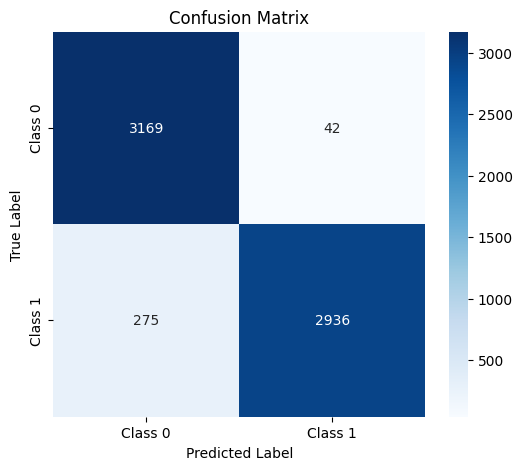

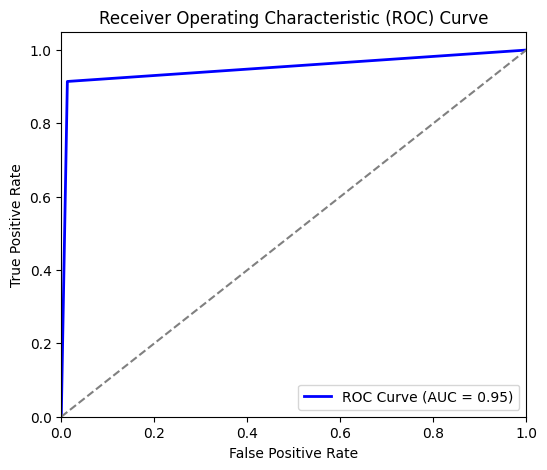

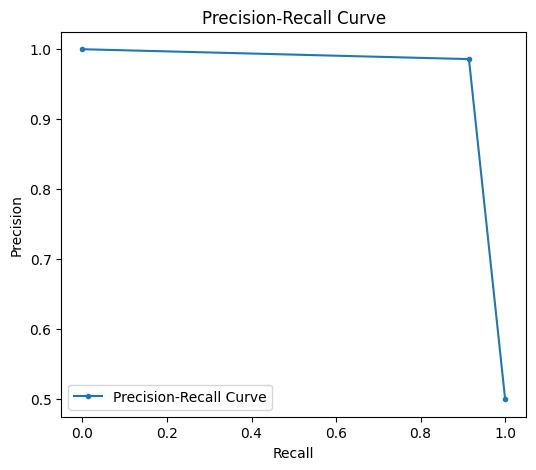

unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.


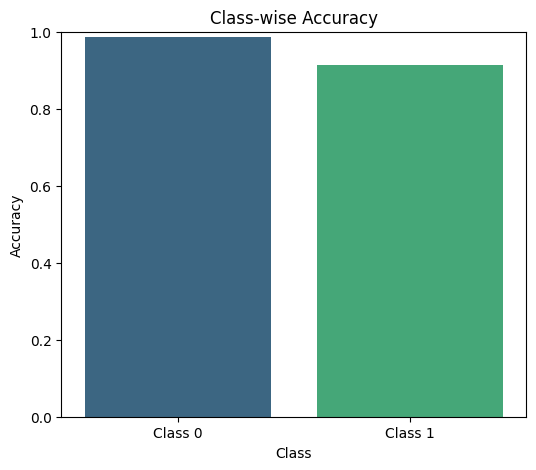

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


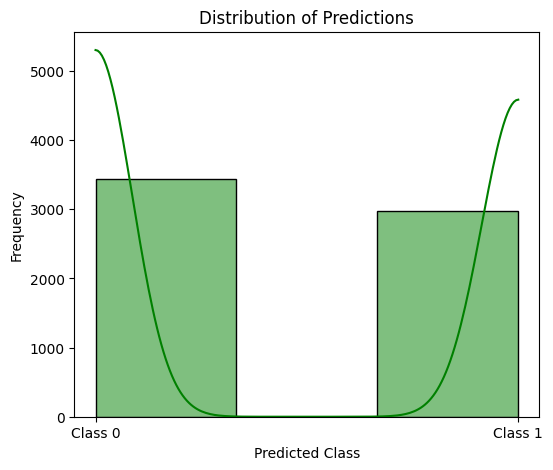



`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


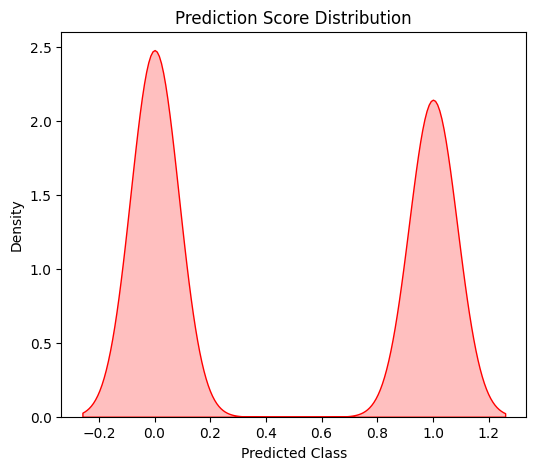

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# Convert lists to NumPy arrays
datalabels = np.array(datalabels)
predictions = np.array(predictions)

## 1️⃣ Confusion Matrix (Heatmap)
plt.figure(figsize=(6, 5))
cf_matrix = confusion_matrix(datalabels, predictions, labels=[0, 1])
sns.heatmap(cf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=["Class 0", "Class 1"], yticklabels=["Class 0", "Class 1"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

## 2️⃣ ROC Curve (Receiver Operating Characteristic)
fpr, tpr, _ = roc_curve(datalabels, predictions)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="grey", linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.show()

## 3️⃣ Precision-Recall Curve
precision, recall, _ = precision_recall_curve(datalabels, predictions)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, marker=".", label="Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

## 4️⃣ Bar Chart for Class-wise Accuracy
class_labels = ["Class 0", "Class 1"]
correct = [np.sum((datalabels == 0) & (predictions == 0)), np.sum((datalabels == 1) & (predictions == 1))]
total = [np.sum(datalabels == 0), np.sum(datalabels == 1)]
accuracy_per_class = [c / t for c, t in zip(correct, total)]

plt.figure(figsize=(6, 5))
sns.barplot(x=class_labels, y=accuracy_per_class, palette="viridis")
plt.ylim(0, 1)
plt.xlabel("Class")
plt.ylabel("Accuracy")
plt.title("Class-wise Accuracy")
plt.show()

## 5️⃣ Histogram of Model Predictions
plt.figure(figsize=(6, 5))
sns.histplot(predictions, bins=3, kde=True, color="green")
plt.xlabel("Predicted Class")
plt.ylabel("Frequency")
plt.title("Distribution of Predictions")
plt.xticks([0, 1], ["Class 0", "Class 1"])
plt.show()

## 6️⃣ Distribution of Prediction Scores (KDE Plot)
plt.figure(figsize=(6, 5))
sns.kdeplot(predictions, shade=True, color="red")
plt.xlabel("Predicted Class")
plt.ylabel("Density")
plt.title("Prediction Score Distribution")
plt.show()


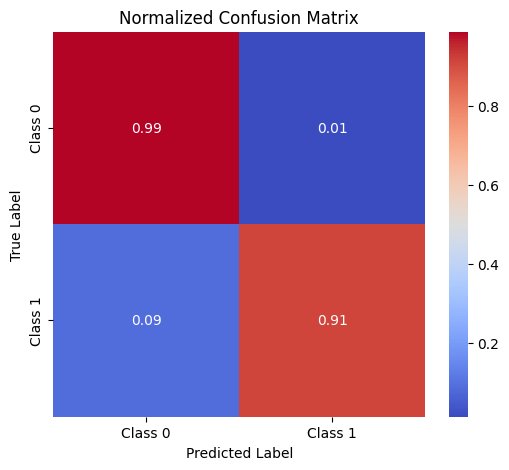

unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.


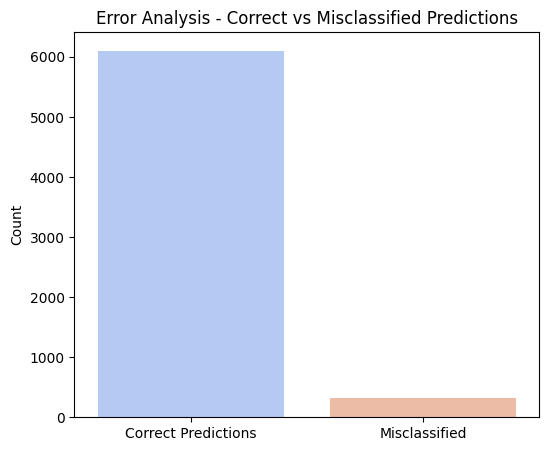

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


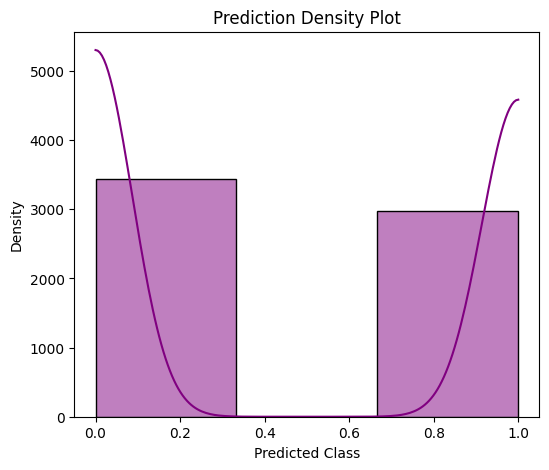

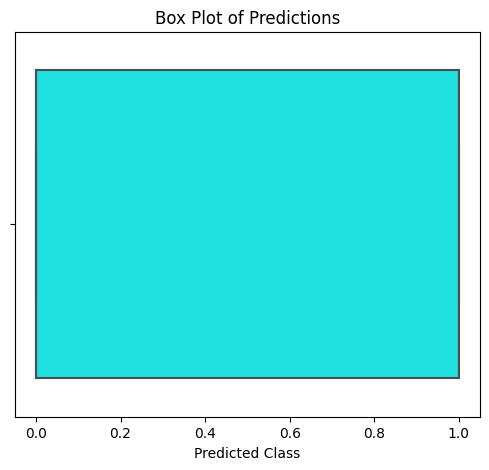

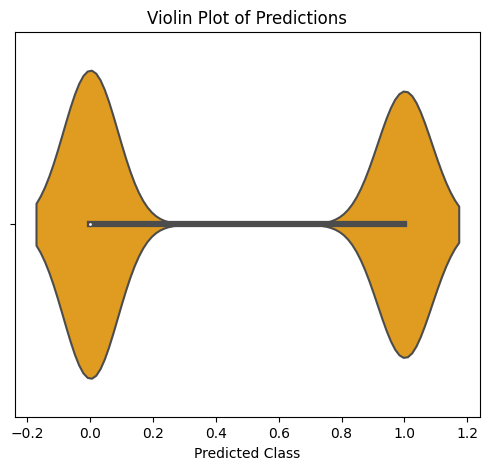

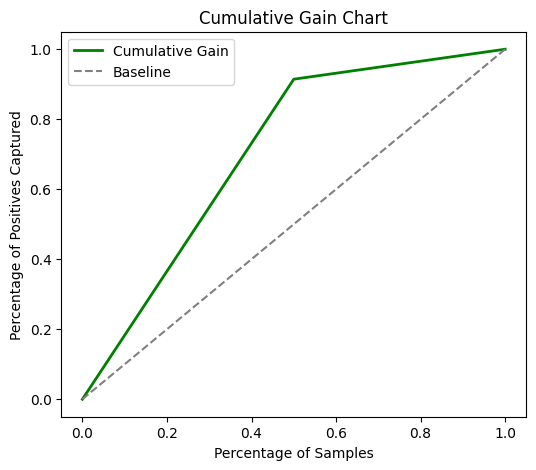

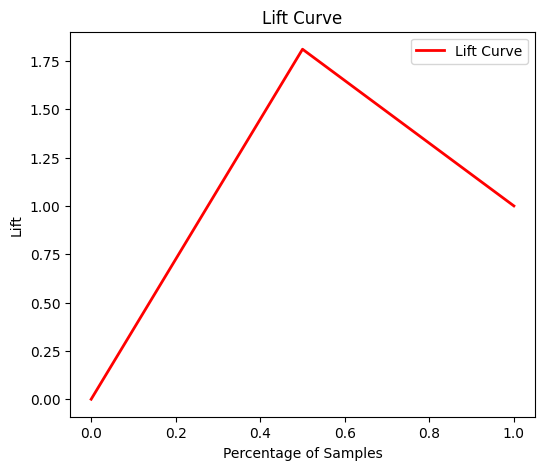

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve

# Convert lists to NumPy arrays
datalabels = np.array(datalabels)
predictions = np.array(predictions)

# 1️⃣ Normalized Confusion Matrix
plt.figure(figsize=(6, 5))
cf_matrix = confusion_matrix(datalabels, predictions, labels=[0, 1])
cf_matrix_normalized = cf_matrix.astype('float') / cf_matrix.sum(axis=1)[:, np.newaxis]
sns.heatmap(cf_matrix_normalized, annot=True, cmap="coolwarm", fmt=".2f", xticklabels=["Class 0", "Class 1"], yticklabels=["Class 0", "Class 1"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix")
plt.show()

# 2️⃣ Error Analysis (Misclassification Bar Plot)
errors = (datalabels != predictions).astype(int)
error_counts = np.bincount(errors)

plt.figure(figsize=(6, 5))
sns.barplot(x=["Correct Predictions", "Misclassified"], y=error_counts, palette="coolwarm")
plt.ylabel("Count")
plt.title("Error Analysis - Correct vs Misclassified Predictions")
plt.show()

# 3️⃣ Prediction Density Plot
plt.figure(figsize=(6, 5))
sns.histplot(predictions, kde=True, bins=3, color="purple")
plt.xlabel("Predicted Class")
plt.ylabel("Density")
plt.title("Prediction Density Plot")
plt.show()

# 4️⃣ Box Plot of Predictions
plt.figure(figsize=(6, 5))
sns.boxplot(x=predictions, color="cyan")
plt.xlabel("Predicted Class")
plt.title("Box Plot of Predictions")
plt.show()

# 5️⃣ Violin Plot for Predictions
plt.figure(figsize=(6, 5))
sns.violinplot(x=predictions, color="orange")
plt.xlabel("Predicted Class")
plt.title("Violin Plot of Predictions")
plt.show()

# 6️⃣ Cumulative Gain Chart
fpr, tpr, _ = roc_curve(datalabels, predictions)
plt.figure(figsize=(6, 5))
plt.plot(np.linspace(0, 1, len(tpr)), tpr, color="green", lw=2, label="Cumulative Gain")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Baseline")
plt.xlabel("Percentage of Samples")
plt.ylabel("Percentage of Positives Captured")
plt.title("Cumulative Gain Chart")
plt.legend()
plt.show()

# 7️⃣ Lift Curve
plt.figure(figsize=(6, 5))
plt.plot(np.linspace(0, 1, len(tpr)), tpr / np.linspace(0.01, 1, len(tpr)), color="red", lw=2, label="Lift Curve")
plt.xlabel("Percentage of Samples")
plt.ylabel("Lift")
plt.title("Lift Curve")
plt.legend()
plt.show()


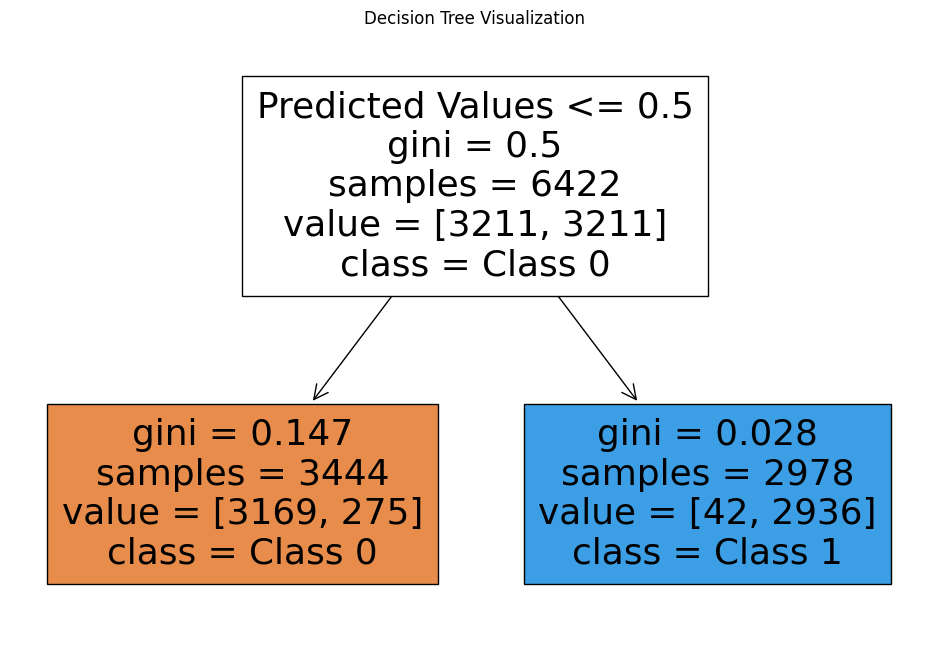

In [52]:

from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Train a simple decision tree
tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(np.array(predictions).reshape(-1, 1), datalabels)

# Plot the decision tree
plt.figure(figsize=(12, 8))
plot_tree(tree_model, filled=True, feature_names=["Predicted Values"], class_names=["Class 0", "Class 1"])
plt.title("Decision Tree Visualization")
plt.show()
